# 1 - Importing necessary libraries

In [1]:
%%time
import xarray as xr
import matplotlib.pylab as plt
import numpy as np
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import scipy.spatial.qhull as qhull
import matplotlib.tri as mtri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import cm
%matplotlib inline

import intake

from aqua import Reader, catalogue
# catalogue(configdir='/home/a/a270223/AQUA/config')
catalogue(configdir='/work/ab0995/a270223/AQUA/config')
# path = '/home/a/a270223/AQUA/config/levante/catalog.yaml'
path = '/work/ab0995/a270223/AQUA/config/levante/catalog.yaml'

CPU times: user 2.07 s, sys: 14.7 s, total: 16.7 s
Wall time: 6.21 s


# 2 - Getting data from the intake catalogue via the Reader function

In [2]:
reader = Reader(model="FESOM", exp="tco2559-ng5", source="original_2d", regrid="r005")
fesom_cat = reader.retrieve(fix=False)

This is the original ungridded fesom dataset.

In [3]:
fesom_cat

<xarray.Dataset>
Dimensions:   (time: 8328, nod2: 7402886)
Coordinates:
  * time      (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T23:56:00
Dimensions without coordinates: nod2
Data variables: (12/19)
    MLD1      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    MLD2      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    a_ice     (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmice_x  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmice_y  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    atmoce_x  (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    ...        ...
    ssh       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    sss       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    sst       (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    uice      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    vice      (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
    vve_5     (time, nod2) float32 dask.array<chunksize=(1, 7402886), meta=np.ndarray>
Attributes: (12/17)
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       469e74b1
    FESOM_MeshPath:                      /ec/res4/scratch/natr/RAPS/20/inputs...
    FESOM_mesh_representative_checksum:  
    FESOM_ClimateDataPath:               /ec/res4/scratch/natr/RAPS/20/inputs...
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      1
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    -1
    history:                             2023-04-14 16:00:00 retrieved by AQU...

# 3 - Selecting Sea Surface Height data from the entire Fesom dataset

In [4]:
fesom_ssh = fesom_cat['ssh']
fesom_ssh

<xarray.DataArray 'ssh' (time: 8328, nod2: 7402886)>
dask.array<concatenate, shape=(8328, 7402886), dtype=float32, chunksize=(1, 7402886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-12-31T23:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    sea surface elevation
    units:        m

Loading a slice of timestamps to analyze

In [5]:
fesom_ssh_slice = fesom_ssh.isel(time=slice(0,20))
fesom_ssh_slice.load()
fesom_ssh_slice

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object not 

<xarray.DataArray 'ssh' (time: 20, nod2: 7402886)>
array([[-1.4822587, -1.4870551, -1.5005083, ..., -1.5007704, -1.5179586,
        -1.4964702],
       [-1.4857868, -1.4905175, -1.5039029, ..., -1.5040525, -1.5211563,
        -1.4998783],
       [-1.4894757, -1.4939175, -1.5072508, ..., -1.5077718, -1.5247712,
        -1.5037994],
       ...,
       [-1.4959148, -1.5030663, -1.5183834, ..., -1.5200399, -1.5373833,
        -1.5153048],
       [-1.4945097, -1.501874 , -1.5174116, ..., -1.519204 , -1.5366738,
        -1.5143065],
       [-1.4928124, -1.5002924, -1.5160494, ..., -1.5176133, -1.5352305,
        -1.5124849]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-20T00:56:00 ... 2020-01-20T19:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    sea surface elevation
    units:        m

Calculating standard deviation on this subset of data

<xarray.DataArray 'ssh' (nod2: 7402886)>
array([0.00405426, 0.00453779, 0.00507028, ..., 0.00555951, 0.0055442 ,
       0.00562045], dtype=float32)
Dimensions without coordinates: nod2


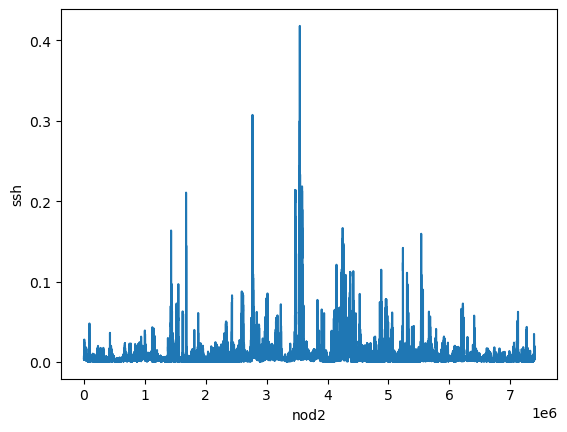

In [6]:
fesom_ssh_slice_std = fesom_ssh_slice.std(dim='time')
print(fesom_ssh_slice_std)
fesom_ssh_slice_std.plot()

Trying to calculate std by reading only parts of data at a time.

In [7]:
%%time
sums = []
n = 0
for entry in fesom_ssh_slice:
    sums.append(entry.sum())
    n += entry.count()
mean = np.array(sums).sum() / n 
mean

CPU times: user 283 ms, sys: 133 ms, total: 416 ms
Wall time: 596 ms


<xarray.DataArray 'ssh' ()>
array(-0.28864486)
Coordinates:
    time     datetime64[ns] 2020-01-20T00:56:00

In [8]:
%%time
from math import sqrt
sum_square_mean_diff = 0
for entry in fesom_ssh_slice:
    sum_square_mean_diff += ((entry - mean) ** 2).sum()
std = sqrt(sum_square_mean_diff / n)
std

CPU times: user 446 ms, sys: 360 ms, total: 806 ms
Wall time: 811 ms


0.6670170288317562

This gives the same result as using .mean() and .std() which reads all data at once.

In [9]:
print(fesom_ssh_slice.mean())
print(fesom_ssh_slice.std())

<xarray.DataArray 'ssh' ()>
array(-0.28864598, dtype=float32)
<xarray.DataArray 'ssh' ()>
array(0.6670175, dtype=float32)


# 4 - Regridding the std dataset using the AQUA regridder

In [10]:
fesom_ssh_slice_std_regrid = reader.regrid(fesom_ssh_slice_std)
fesom_ssh_slice_std_regrid

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 494 in H5O__attr_open_by_name(): can't locate attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Object not found
HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Ao

<xarray.DataArray 'ssh' (lat: 3600, lon: 7200)>
dask.array<reshape, shape=(3600, 7200), dtype=float64, chunksize=(3600, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.88 89.92 89.97
  * lon      (lon) float64 0.0 0.05 0.1 0.15 0.2 ... 359.8 359.9 359.9 359.9
Attributes:
    regridded:  1
    history:    2023-04-14 16:17:23 regridded by AQUA fixer;\n

# 5 - Visualizing the data